In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Path("../outputs/figures").mkdir(parents=True, exist_ok=True)

diabetes = pd.read_csv("../data/processed/india_diabetes_burden_clean.csv")
determinants = pd.read_csv("../data/processed/india_determinants_panel.csv")
vdem = pd.read_csv("../data/processed/india_vdem_freedom.csv")

panel = diabetes.merge(determinants, on="year", how="left")
panel = panel.merge(vdem, on="year", how="left")

panel = panel.sort_values("year").reset_index(drop=True)

panel.head()

,year,DALYs (Disability-Adjusted Life Years),Deaths,Incidence,Prevalence,YLDs (Years Lived with Disability),YLLs (Years of Life Lost),gdp_per_capita,poverty_headcount,health_expenditure_gdp,out_of_pocket_health_exp,secondary_school_enrolment,urban_population_pct,internet_users_pct,population_65plus_pct,liberal_democracy_index
0,1990,949.405983,26.559467,202.431917,4429.816049,345.628099,603.777893,371.085936,NaN,NaN,NaN,NaN,25.578402,0.000000,4.037870,0.540
1,1991,960.769871,26.680584,202.889033,4428.289730,354.928093,605.841787,305.574056,NaN,NaN,NaN,NaN,25.779761,NaN,4.058414,0.561
2,1992,971.164072,26.796212,203.663534,4458.347037,364.412942,606.751139,319.182473,NaN,NaN,NaN,NaN,25.980858,0.000111,4.083406,0.572
3,1993,973.649743,26.534771,204.702504,4503.289644,372.856341,600.793412,302.884806,45.3,NaN,NaN,44.849522,26.176781,0.000218,4.112483,0.576
4,1994,980.484220,26.665199,205.952956,4546.535606,379.054940,601.429290,347.734215,NaN,NaN,NaN,45.168720,26.371019,0.001070,4.146189,0.582


In [2]:
panel.to_csv(
    "../data/processed/india_diabetes_scenario_panel.csv",
    index=False
)

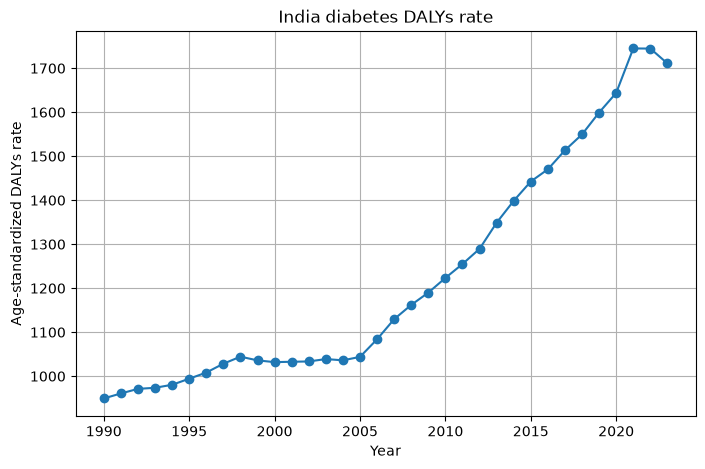

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(panel["year"], panel["DALYs (Disability-Adjusted Life Years)"], marker="o")
plt.title("India diabetes DALYs rate")
plt.xlabel("Year")
plt.ylabel("Age-standardized DALYs rate")
plt.grid(True)
plt.savefig("../outputs/figures/india_diabetes_dalys_trend.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
list(panel.columns)


['year',
 'DALYs (Disability-Adjusted Life Years)',
 'Deaths',
 'Incidence',
 'Prevalence',
 'YLDs (Years Lived with Disability)',
 'YLLs (Years of Life Lost)',
 'gdp_per_capita',
 'poverty_headcount',
 'health_expenditure_gdp',
 'out_of_pocket_health_exp',
 'secondary_school_enrolment',
 'urban_population_pct',
 'internet_users_pct',
 'population_65plus_pct',
 'liberal_democracy_index']

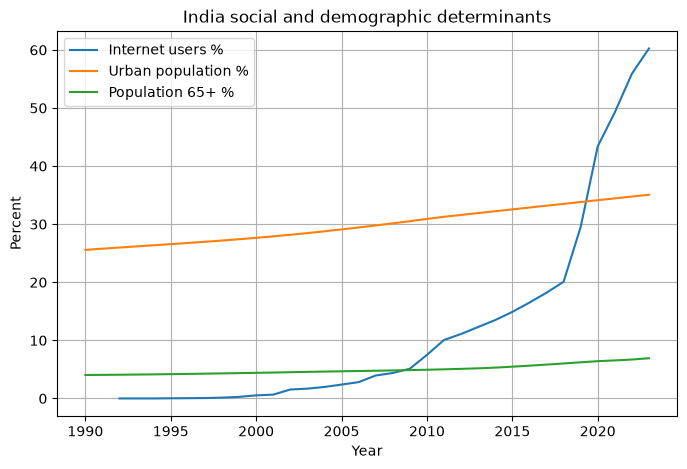

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(panel["year"], panel["internet_users_pct"], label="Internet users %")
plt.plot(panel["year"], panel["urban_population_pct"], label="Urban population %")
plt.plot(panel["year"], panel["population_65plus_pct"], label="Population 65+ %")

plt.title("India social and demographic determinants")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.legend()
plt.grid(True)

plt.savefig("../outputs/figures/india_social_determinants.png", dpi=300, bbox_inches="tight")
plt.show()

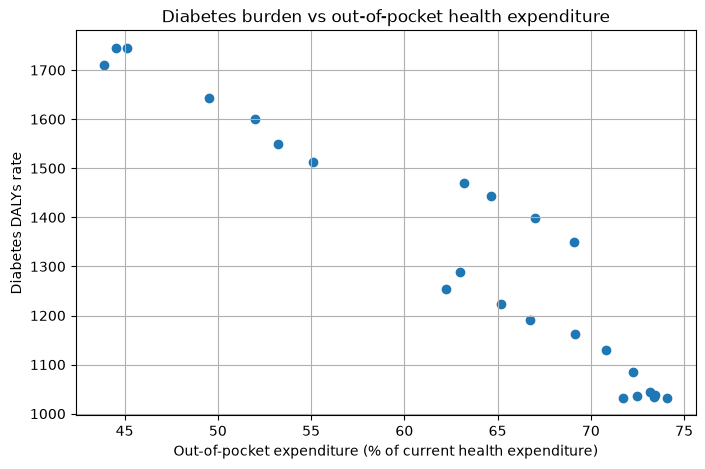

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(panel["out_of_pocket_health_exp"], panel["DALYs (Disability-Adjusted Life Years)"])

plt.title("Diabetes burden vs out-of-pocket health expenditure")
plt.xlabel("Out-of-pocket expenditure (% of current health expenditure)")
plt.ylabel("Diabetes DALYs rate")
plt.grid(True)

plt.savefig("../outputs/figures/diabetes_vs_oop_health_exp.png", dpi=300, bbox_inches="tight")
plt.show()